# HRC Industrial Metals Dislocation Investigation

This notebook investigates the second candidate strategy from the MFT strategy review: HRC-driven industrial-metals relative-value dislocations.

The core concern is liquidity. HRC has far fewer one-minute updates than HG, GC, SI, or PL, so the test uses a daily HRC-driven clock instead of exact one-minute common timestamps. The strategy is deliberately low-turnover: enter only on large rolling residual dislocations, delay execution by one active daily bar, and apply asset-specific turnover costs.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (13, 6),
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

DATA_DIR = Path("/home/famadeo/research/databento-asset-browser/data/metals_1m_10y/continuous")
ROOTS = ["HRC", "HG", "ALI", "GC", "SI", "PL", "PA"]
START_TS = pd.Timestamp("2020-01-01", tz="UTC")

# Conservative per-unit-turnover cost assumptions in bps.
COST_BPS = {
    "HRC": 5.0,
    "HG": 1.5,
    "ALI": 3.0,
    "GC": 1.0,
    "SI": 1.5,
    "PL": 2.0,
    "PA": 3.0,
}

EXECUTION_LAG_DAYS = 1
MIN_HRC_DAILY_VOLUME = 10
ROLL_PAUSE_DAYS = {"HRC": 2, "default": 1}

## 1. Coverage And Liquidity

HRC is sparse compared with the rest of the metals panel. The daily frame below uses each root's last continuous log price on active days, plus daily volume, active-bar count, and roll flags.


In [2]:
def load_daily_root(root: str) -> pd.DataFrame:
    frame = (
        pd.read_parquet(
            DATA_DIR / f"{root}.parquet",
            columns=["ts", "cont_logprice", "volume", "is_roll"],
        )
        .dropna(subset=["cont_logprice"])
        .sort_values("ts")
    )
    frame = frame.loc[frame["ts"] >= START_TS].copy()
    frame["date"] = frame["ts"].dt.floor("D")
    grouped = frame.groupby("date", sort=True)
    return pd.DataFrame(
        {
            root: grouped["cont_logprice"].last(),
            f"{root}_volume": grouped["volume"].sum(),
            f"{root}_bars": grouped["ts"].size(),
            f"{root}_roll": grouped["is_roll"].max(),
            f"{root}_first_ts": grouped["ts"].min(),
            f"{root}_last_ts": grouped["ts"].max(),
        }
    )


def load_intraday_root(root: str) -> pd.DataFrame:
    frame = (
        pd.read_parquet(
            DATA_DIR / f"{root}.parquet",
            columns=["ts", "cont_logprice", "volume", "is_roll"],
        )
        .dropna(subset=["cont_logprice"])
        .sort_values("ts")
    )
    return frame.loc[frame["ts"] >= START_TS].copy()


daily_roots = {root: load_daily_root(root) for root in ROOTS}
daily_panel = pd.concat(daily_roots.values(), axis=1).sort_index()

coverage_rows = []
for root in ROOTS:
    intraday = load_intraday_root(root)
    active_days = daily_roots[root]
    coverage_rows.append(
        {
            "root": root,
            "rows": len(intraday),
            "start": intraday["ts"].min(),
            "end": intraday["ts"].max(),
            "active_days": len(active_days),
            "median_bars_per_active_day": active_days[f"{root}_bars"].median(),
            "p10_bars_per_active_day": active_days[f"{root}_bars"].quantile(0.10),
            "p90_bars_per_active_day": active_days[f"{root}_bars"].quantile(0.90),
            "median_daily_volume": active_days[f"{root}_volume"].median(),
        }
    )
coverage = pd.DataFrame(coverage_rows)
display(coverage)

overlap_rows = []
for roots in [["HRC", "HG"], ["HRC", "ALI"], ["HRC", "HG", "ALI"], ROOTS]:
    overlap_rows.append(
        {
            "roots": "/".join(roots),
            "daily_overlap_days": int(daily_panel[roots].dropna().shape[0]),
        }
    )
display(pd.DataFrame(overlap_rows))

,root,rows,start,end,active_days,median_bars_per_active_day,p10_bars_per_active_day,p90_bars_per_active_day,median_daily_volume
0,HRC,25153,2020-01-02 15:18:00+00:00,2026-06-21 22:00:00+00:00,1724,10.0,2.0,30.0,48.0
1,HG,2202669,2020-01-01 23:00:00+00:00,2026-06-21 23:59:00+00:00,2011,1311.0,101.0,1357.0,47129.0
2,ALI,158206,2020-01-03 10:06:00+00:00,2026-06-21 23:50:00+00:00,1667,68.0,6.0,220.4,350.0
3,GC,2286938,2020-01-01 23:00:00+00:00,2026-06-21 23:59:00+00:00,2011,1376.0,120.0,1380.0,152812.0
4,SI,2209344,2020-01-01 23:00:00+00:00,2026-06-21 23:59:00+00:00,2011,1313.0,106.0,1366.0,49205.0
5,PL,1923389,2020-01-01 23:00:00+00:00,2026-06-21 23:58:00+00:00,2011,1117.0,73.0,1278.0,15551.0
6,PA,861703,2020-01-01 23:00:00+00:00,2026-06-21 23:55:00+00:00,2010,406.0,21.0,771.1,1849.5


,roots,daily_overlap_days
0,HRC/HG,1724
1,HRC/ALI,1624
2,HRC/HG/ALI,1624
3,HRC/HG/ALI/GC/SI/PL/PA,1624


## 2. Strategy Definition

For each candidate factor basket, the strategy:

1. Builds daily close-to-close returns on common HRC/factor active days.
2. Estimates HRC beta to the equal-weight factor return with a shifted rolling window.
3. Cum-sums the beta-hedged residual return.
4. Enters when the residual robust z-score is beyond the entry threshold.
5. Executes with a one active-day lag.
6. Holds until the residual normalizes, the max hold is reached, or the residual moves materially further against the trade.

Positions are normalized to one unit gross exposure: 50% HRC and 50% factor basket. Costs are asset-specific and charged on turnover.


In [3]:
def roll_pause_mask(rolls: pd.Series, pause_days: int) -> pd.Series:
    rolls = rolls.fillna(False).astype(bool)
    paused = pd.Series(False, index=rolls.index)
    roll_indices = np.flatnonzero(rolls.to_numpy(dtype=bool))
    for idx in roll_indices:
        start = max(0, idx - pause_days)
        end = min(len(paused), idx + pause_days + 1)
        paused.iloc[start:end] = True
    return paused


def robust_zscore(series: pd.Series, lookback: int) -> pd.Series:
    median = series.rolling(lookback, min_periods=lookback // 2).median().shift(1)
    q25 = series.rolling(lookback, min_periods=lookback // 2).quantile(0.25).shift(1)
    q75 = series.rolling(lookback, min_periods=lookback // 2).quantile(0.75).shift(1)
    sigma = ((q75 - q25) / 1.349).replace(0.0, np.nan)
    return ((series - median) / sigma).replace([np.inf, -np.inf], np.nan)


def state_from_zscore(
    zscore: pd.Series,
    *,
    entry_z: float,
    exit_z: float,
    stop_z: float,
    max_hold_days: int,
) -> pd.Series:
    values = zscore.to_numpy(dtype=float)
    state_values = np.zeros(len(zscore), dtype=float)
    state = 0.0
    holding_days = 0
    for idx, value in enumerate(values):
        if not np.isfinite(value):
            state = 0.0
            holding_days = 0
            state_values[idx] = 0.0
            continue

        if state != 0.0:
            holding_days += 1
            if (
                abs(value) <= exit_z
                or holding_days >= max_hold_days
                or (state < 0.0 and value >= stop_z)
                or (state > 0.0 and value <= -stop_z)
            ):
                state = 0.0
                holding_days = 0

        if state == 0.0:
            if value >= entry_z:
                state = -1.0
                holding_days = 0
            elif value <= -entry_z:
                state = 1.0
                holding_days = 0

        state_values[idx] = state
    return pd.Series(state_values, index=zscore.index)


def metric_block(
    returns: pd.Series, gross: pd.Series, cost: pd.Series, positions: pd.DataFrame
) -> dict[str, object]:
    returns = returns.dropna()
    gross = gross.reindex(returns.index).fillna(0.0)
    cost = cost.reindex(returns.index).fillna(0.0)
    positions = positions.reindex(returns.index).fillna(0.0)
    if returns.empty:
        return {}

    equity = returns.cumsum()
    drawdown = equity - equity.cummax()
    calendar_days = (returns.index[-1] - returns.index[0]).total_seconds() / 86_400.0
    bars_per_year = len(returns) / calendar_days * 365.25 if calendar_days > 0 else np.nan
    std = returns.std(ddof=1)
    trade_count = int(
        (
            positions.abs().sum(axis=1).gt(0.0)
            & positions.abs().sum(axis=1).shift(1, fill_value=0.0).eq(0.0)
        ).sum()
    )
    return {
        "observations": int(len(returns)),
        "start": returns.index[0],
        "end": returns.index[-1],
        "gross_log_return": float(gross.sum()),
        "cost_log_return": float(cost.sum()),
        "net_log_return": float(returns.sum()),
        "compounded_net_return": float(np.expm1(returns.sum())),
        "gross_to_cost": float(gross.sum() / cost.sum()) if cost.sum() > 0 else np.nan,
        "bar_tstat": float(returns.mean() / std * np.sqrt(len(returns))) if std > 0 else np.nan,
        "annualized_sharpe": float(returns.mean() / std * np.sqrt(bars_per_year))
        if std > 0 and np.isfinite(bars_per_year)
        else np.nan,
        "max_drawdown_log": float(drawdown.min()),
        "active_fraction": float(positions.abs().sum(axis=1).gt(0.0).mean()),
        "trades": trade_count,
    }


def extract_trades(returns: pd.DataFrame, positions: pd.DataFrame) -> pd.DataFrame:
    active = positions.abs().sum(axis=1) > 0.0
    trade_rows = []
    entry_idx = None
    for timestamp, is_active in active.items():
        was_active = bool(active.shift(1, fill_value=False).loc[timestamp])
        if is_active and not was_active:
            entry_idx = timestamp
        elif not is_active and was_active and entry_idx is not None:
            trade_slice = returns.loc[entry_idx:timestamp]
            trade_rows.append(
                {
                    "entry": entry_idx,
                    "exit": timestamp,
                    "holding_days": len(trade_slice),
                    "gross_log_return": trade_slice["gross_return"].sum(),
                    "cost_log_return": trade_slice["cost_return"].sum(),
                    "net_log_return": trade_slice["net_return"].sum(),
                }
            )
            entry_idx = None
    if entry_idx is not None:
        trade_slice = returns.loc[entry_idx:]
        trade_rows.append(
            {
                "entry": entry_idx,
                "exit": trade_slice.index[-1],
                "holding_days": len(trade_slice),
                "gross_log_return": trade_slice["gross_return"].sum(),
                "cost_log_return": trade_slice["cost_return"].sum(),
                "net_log_return": trade_slice["net_return"].sum(),
            }
        )
    return pd.DataFrame(trade_rows)


def run_hrc_dislocation_strategy(
    factors: tuple[str, ...],
    *,
    lookback_days: int = 126,
    entry_z: float = 2.0,
    exit_z: float = 0.25,
    stop_z: float = 4.0,
    max_hold_days: int = 21,
    min_hrc_volume: float = MIN_HRC_DAILY_VOLUME,
    cost_multiplier: float = 1.0,
) -> dict[str, object]:
    roots = ("HRC", *factors)
    columns = []
    for root in roots:
        columns.extend([root, f"{root}_volume", f"{root}_bars", f"{root}_roll"])
    frame = daily_panel[columns].dropna().copy()
    prices = frame[list(roots)]
    returns = prices.diff()

    valid = frame["HRC_volume"].ge(min_hrc_volume) & frame["HRC_bars"].ge(2)
    paused = roll_pause_mask(frame["HRC_roll"], ROLL_PAUSE_DAYS["HRC"])
    for root in factors:
        valid &= frame[f"{root}_volume"].gt(0.0)
        paused |= roll_pause_mask(frame[f"{root}_roll"], ROLL_PAUSE_DAYS["default"])

    factor_return = returns[list(factors)].mean(axis=1)
    hrc_return = returns["HRC"]
    beta = (
        (
            hrc_return.rolling(lookback_days, min_periods=lookback_days // 2)
            .cov(factor_return)
            .shift(1)
            / factor_return.rolling(lookback_days, min_periods=lookback_days // 2)
            .var()
            .shift(1)
            .replace(0.0, np.nan)
        )
        .clip(-3.0, 3.0)
        .fillna(1.0)
    )
    residual_return = hrc_return - beta * factor_return
    residual = residual_return.cumsum()
    zscore = robust_zscore(residual, lookback_days).where(valid & ~paused)

    signal_state = state_from_zscore(
        zscore,
        entry_z=entry_z,
        exit_z=exit_z,
        stop_z=stop_z,
        max_hold_days=max_hold_days,
    )
    side = signal_state.shift(EXECUTION_LAG_DAYS).fillna(0.0)

    positions = pd.DataFrame(0.0, index=frame.index, columns=list(roots))
    positions["HRC"] = 0.5 * side
    for root in factors:
        positions[root] = -(0.5 / len(factors)) * side
    positions = positions.where(valid & ~paused, 0.0)

    forward_returns = returns.shift(-1).reindex(positions.index)
    gross_return = (positions * forward_returns[list(roots)]).sum(axis=1).iloc[:-1]
    turnover = positions.diff().abs().fillna(positions.abs()).iloc[:-1]
    cost_return = sum(
        turnover[root] * (COST_BPS[root] * cost_multiplier / 10_000.0) for root in roots
    )
    result = pd.DataFrame(
        {
            "gross_return": gross_return,
            "cost_return": cost_return,
            "net_return": gross_return - cost_return,
            "residual": residual.reindex(gross_return.index),
            "zscore": zscore.reindex(gross_return.index),
            "side": side.reindex(gross_return.index),
            "valid": valid.reindex(gross_return.index).fillna(False),
            "paused": paused.reindex(gross_return.index).fillna(False),
        }
    )
    positions = positions.reindex(result.index).fillna(0.0)
    metrics = metric_block(
        result["net_return"], result["gross_return"], result["cost_return"], positions
    )
    metrics.update(
        {
            "factors": "+".join(factors),
            "lookback_days": lookback_days,
            "entry_z": entry_z,
            "exit_z": exit_z,
            "stop_z": stop_z,
            "max_hold_days": max_hold_days,
            "min_hrc_volume": min_hrc_volume,
            "cost_multiplier": cost_multiplier,
        }
    )
    trades = extract_trades(result, positions)
    return {
        "result": result,
        "positions": positions,
        "metrics": metrics,
        "trades": trades,
        "zscore": zscore,
        "residual": residual,
        "beta": beta,
    }

## 3. Parameter Scan

The scan is intentionally small. It varies the factor basket, lookback, entry threshold, and maximum hold while keeping the liquidity and roll filters fixed. The primary economic metric is gross return divided by modeled turnover cost.


In [4]:
factor_sets = [
    ("HG",),
    ("ALI",),
    ("HG", "ALI"),
    ("HG", "ALI", "GC", "SI"),
    ("HG", "ALI", "PL", "PA"),
]
lookbacks = [63, 126, 252]
entries = [1.5, 2.0, 2.5]
max_holds = [21, 63, 126]

scan_rows = []
scan_results = {}
for factors in factor_sets:
    for lookback in lookbacks:
        for entry in entries:
            for max_hold in max_holds:
                run = run_hrc_dislocation_strategy(
                    factors,
                    lookback_days=lookback,
                    entry_z=entry,
                    max_hold_days=max_hold,
                )
                row = run["metrics"].copy()
                scan_rows.append(row)
                key = (row["factors"], lookback, entry, max_hold)
                scan_results[key] = run

scan = pd.DataFrame(scan_rows)
scan = scan.sort_values(["net_log_return", "gross_to_cost"], ascending=False)
display(scan.head(20))

economic = scan.loc[(scan["trades"] >= 5) & scan["net_log_return"].gt(0.0)].sort_values(
    "gross_to_cost", ascending=False
)
display(economic.head(20))

/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


...

/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls 

/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls 

/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls 

,observations,start,end,gross_log_return,cost_log_return,net_log_return,compounded_net_return,gross_to_cost,bar_tstat,annualized_sharpe,...,active_fraction,trades,factors,lookback_days,entry_z,exit_z,stop_z,max_hold_days,min_hrc_volume,cost_multiplier
39,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.189859,0.010400,0.179459,0.196569,18.255637,2.211890,0.870352,...,0.033888,13,ALI,126,2.0,0.25,4.0,21,10,1.0
40,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.189859,0.010400,0.179459,0.196569,18.255637,2.211890,0.870352,...,0.033888,13,ALI,126,2.0,0.25,4.0,63,10,1.0
41,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.189859,0.010400,0.179459,0.196569,18.255637,2.211890,0.870352,...,0.033888,13,ALI,126,2.0,0.25,4.0,126,10,1.0
36,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.180220,0.014400,0.165820,0.180361,12.515292,1.820039,0.716163,...,0.048675,18,ALI,126,1.5,0.25,4.0,21,10,1.0
37,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.180220,0.014400,0.165820,0.180361,12.515292,1.820039,0.716163,...,0.048675,18,ALI,126,1.5,0.25,4.0,63,10,1.0
38,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.180220,0.014400,0.165820,0.180361,12.515292,1.820039,0.716163,...,0.048675,18,ALI,126,1.5,0.25,4.0,126,10,1.0
63,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.131847,0.012325,0.119522,0.126958,10.697488,1.542845,0.607090,...,0.046827,17,HG+ALI,126,1.5,0.25,4.0,21,10,1.0
64,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.131847,0.012325,0.119522,0.126958,10.697488,1.542845,0.607090,...,0.046827,17,HG+ALI,126,1.5,0.25,4.0,63,10,1.0
65,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.131847,0.012325,0.119522,0.126958,10.697488,1.542845,0.607090,...,0.046827,17,HG+ALI,126,1.5,0.25,4.0,126,10,1.0
45,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.124673,0.012000,0.112673,0.119266,10.389440,1.289769,0.507508,...,0.039433,15,ALI,252,1.5,0.25,4.0,21,10,1.0


,observations,start,end,gross_log_return,cost_log_return,net_log_return,compounded_net_return,gross_to_cost,bar_tstat,annualized_sharpe,...,active_fraction,trades,factors,lookback_days,entry_z,exit_z,stop_z,max_hold_days,min_hrc_volume,cost_multiplier
70,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.077515,0.003625,0.073890,0.076689,21.383528,1.664870,0.655106,...,0.009858,5,HG+ALI,126,2.5,0.25,4.0,63,10,1.0
71,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.077515,0.003625,0.073890,0.076689,21.383528,1.664870,0.655106,...,0.009858,5,HG+ALI,126,2.5,0.25,4.0,126,10,1.0
69,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.077515,0.003625,0.073890,0.076689,21.383528,1.664870,0.655106,...,0.009858,5,HG+ALI,126,2.5,0.25,4.0,21,10,1.0
53,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.098667,0.004800,0.093867,0.098413,20.555564,1.624288,0.639137,...,0.016636,6,ALI,252,2.5,0.25,4.0,126,10,1.0
51,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.098667,0.004800,0.093867,0.098413,20.555564,1.624288,0.639137,...,0.016636,6,ALI,252,2.5,0.25,4.0,21,10,1.0
52,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.098667,0.004800,0.093867,0.098413,20.555564,1.624288,0.639137,...,0.016636,6,ALI,252,2.5,0.25,4.0,63,10,1.0
40,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.189859,0.010400,0.179459,0.196569,18.255637,2.211890,0.870352,...,0.033888,13,ALI,126,2.0,0.25,4.0,63,10,1.0
41,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.189859,0.010400,0.179459,0.196569,18.255637,2.211890,0.870352,...,0.033888,13,ALI,126,2.0,0.25,4.0,126,10,1.0
39,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.189859,0.010400,0.179459,0.196569,18.255637,2.211890,0.870352,...,0.033888,13,ALI,126,2.0,0.25,4.0,21,10,1.0
75,1623,2020-01-03 00:00:00+00:00,2026-06-19 00:00:00+00:00,0.100099,0.005800,0.094299,0.098888,17.258469,1.562318,0.614753,...,0.026494,8,HG+ALI,252,2.0,0.25,4.0,21,10,1.0


## 4. Selected Candidate: HRC Vs ALI

The initial scan points to the sparse HRC/ALI residual as the strongest candidate. This section fixes the candidate to `lookback=126`, `entry_z=2.0`, `exit_z=0.25`, `max_hold=21`, and then stress-tests costs.


In [5]:
selected_run = run_hrc_dislocation_strategy(
    ("ALI",), lookback_days=126, entry_z=2.0, max_hold_days=21
)
selected = selected_run["result"].copy()
selected_positions = selected_run["positions"].copy()
selected_trades = selected_run["trades"].copy()
selected_metrics = pd.DataFrame([selected_run["metrics"]])

display(selected_metrics.T.rename(columns={0: "HRC_vs_ALI_126_2z"}))
display(selected_trades)

cost_stress_rows = []
for multiplier in [0.5, 1.0, 2.0, 3.0, 5.0]:
    run = run_hrc_dislocation_strategy(
        ("ALI",),
        lookback_days=126,
        entry_z=2.0,
        max_hold_days=21,
        cost_multiplier=multiplier,
    )
    row = run["metrics"].copy()
    cost_stress_rows.append(row)
cost_stress = pd.DataFrame(cost_stress_rows)
display(
    cost_stress[
        [
            "cost_multiplier",
            "trades",
            "gross_log_return",
            "cost_log_return",
            "gross_to_cost",
            "net_log_return",
            "annualized_sharpe",
            "max_drawdown_log",
        ]
    ]
)


def yearly_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for year, group in frame.groupby(frame.index.year):
        rows.append(
            {
                "year": year,
                "gross_log_return": group["gross_return"].sum(),
                "cost_log_return": group["cost_return"].sum(),
                "net_log_return": group["net_return"].sum(),
                "active_days": int(group["side"].abs().gt(0.0).sum()),
            }
        )
    yearly = pd.DataFrame(rows)
    yearly["gross_to_cost"] = yearly["gross_log_return"] / yearly["cost_log_return"].replace(
        0.0, np.nan
    )
    return yearly


yearly = yearly_metrics(selected)
display(yearly)

/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


,HRC_vs_ALI_126_2z
observations,1623
start,2020-01-03 00:00:00+00:00
end,2026-06-19 00:00:00+00:00
gross_log_return,0.189859
cost_log_return,0.0104
net_log_return,0.179459
compounded_net_return,0.196569
gross_to_cost,18.255637
bar_tstat,2.21189
annualized_sharpe,0.870352


,entry,exit,holding_days,gross_log_return,cost_log_return,net_log_return
0,2020-10-28 00:00:00+00:00,2020-10-29 00:00:00+00:00,2,-0.006293,0.0008,-0.007093
1,2022-01-21 00:00:00+00:00,2022-01-27 00:00:00+00:00,5,-0.012785,0.0008,-0.013585
2,2022-12-20 00:00:00+00:00,2022-12-21 00:00:00+00:00,2,0.020698,0.0008,0.019898
3,2023-01-06 00:00:00+00:00,2023-01-16 00:00:00+00:00,7,0.067490,0.0008,0.066690
4,2023-03-20 00:00:00+00:00,2023-03-23 00:00:00+00:00,4,0.042259,0.0008,0.041459
5,2023-10-27 00:00:00+00:00,2023-10-30 00:00:00+00:00,2,-0.005787,0.0008,-0.006587
6,2024-12-24 00:00:00+00:00,2025-01-13 00:00:00+00:00,13,-0.014392,0.0008,-0.015192
7,2026-02-27 00:00:00+00:00,2026-03-01 00:00:00+00:00,2,0.000365,0.0008,-0.000435
8,2026-03-03 00:00:00+00:00,2026-03-08 00:00:00+00:00,5,0.024268,0.0008,0.023468
9,2026-03-10 00:00:00+00:00,2026-03-15 00:00:00+00:00,5,0.026789,0.0008,0.025989


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)
/tmp/ipykernel_275402/269997098.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rolls = rolls.fillna(False).astype(bool)


,cost_multiplier,trades,gross_log_return,cost_log_return,gross_to_cost,net_log_return,annualized_sharpe,max_drawdown_log
0,0.5,13,0.189859,0.0052,36.511275,0.184659,0.894179,-0.029837
1,1.0,13,0.189859,0.0104,18.255637,0.179459,0.870352,-0.030637
2,2.0,13,0.189859,0.0208,9.127819,0.169059,0.822093,-0.032237
3,3.0,13,0.189859,0.0312,6.085212,0.158659,0.773096,-0.035434
4,5.0,13,0.189859,0.0520,3.651127,0.137859,0.673231,-0.041834


,year,gross_log_return,cost_log_return,net_log_return,active_days,gross_to_cost
0,2020,-0.006293,0.0008,-0.007093,2,-7.865728
1,2021,0.000000,0.0000,0.000000,0,NaN
2,2022,0.007914,0.0016,0.006314,7,4.946051
3,2023,0.103962,0.0024,0.101562,15,43.317690
4,2024,-0.005713,0.0004,-0.006113,6,-14.281542
5,2025,-0.008679,0.0004,-0.009079,8,-21.697537
6,2026,0.098667,0.0048,0.093867,33,20.555564


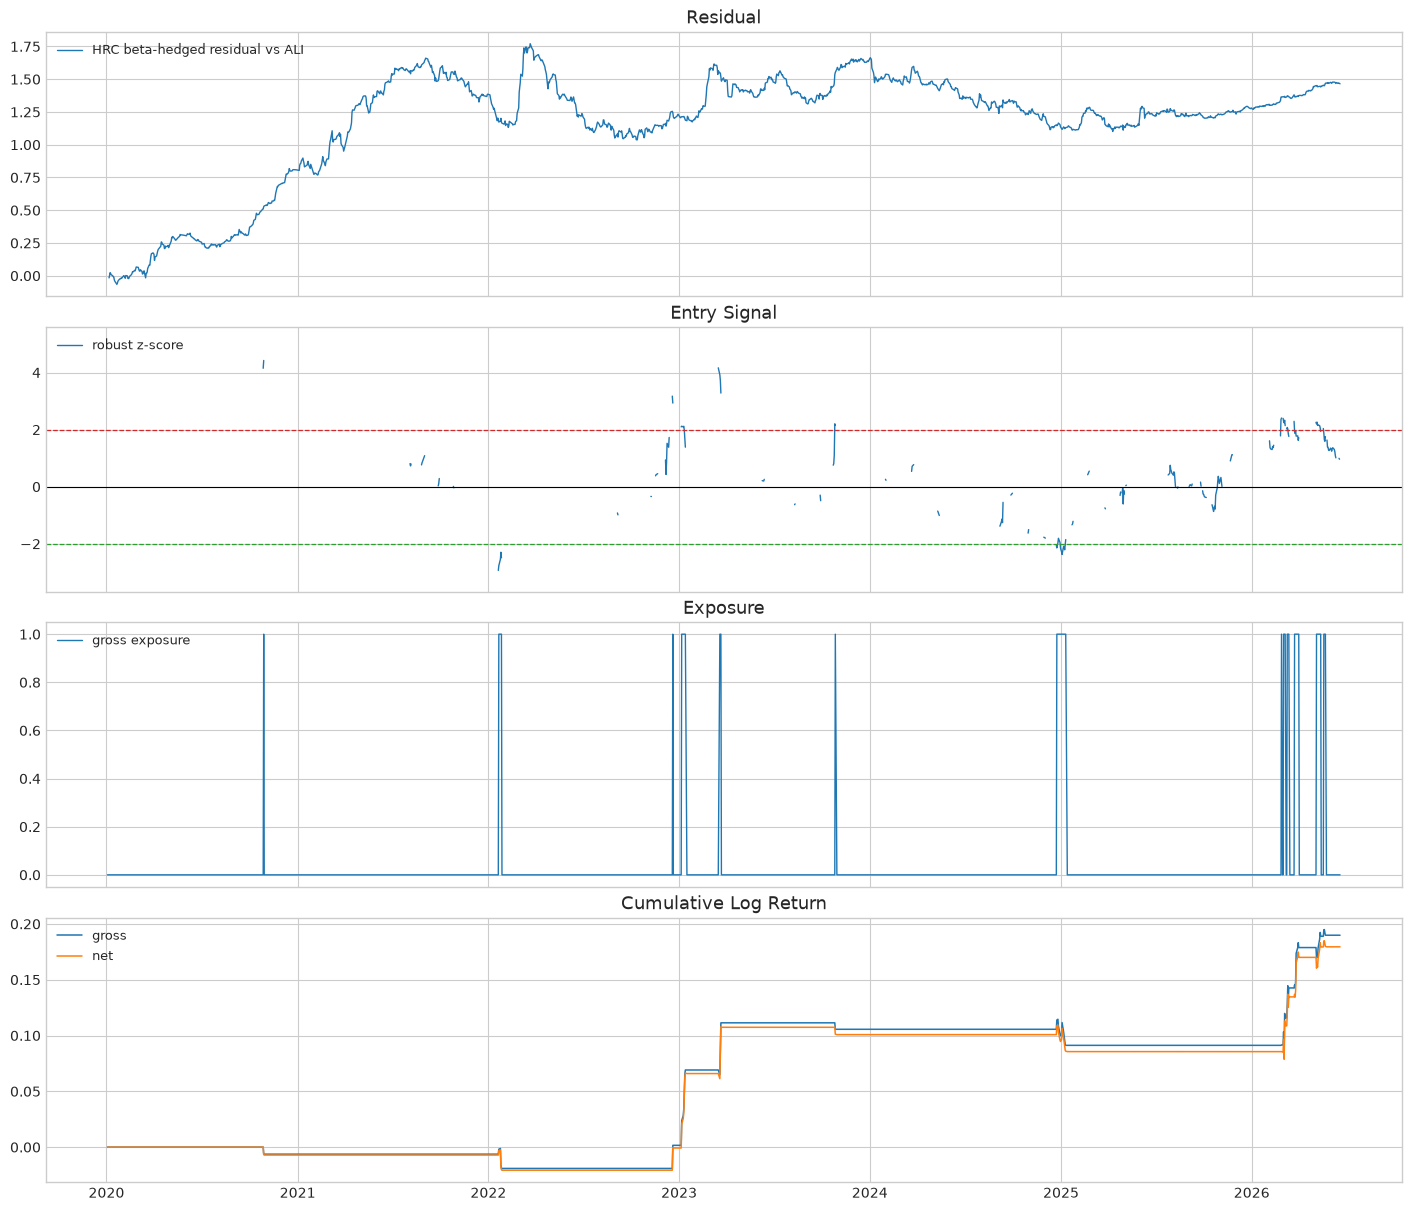

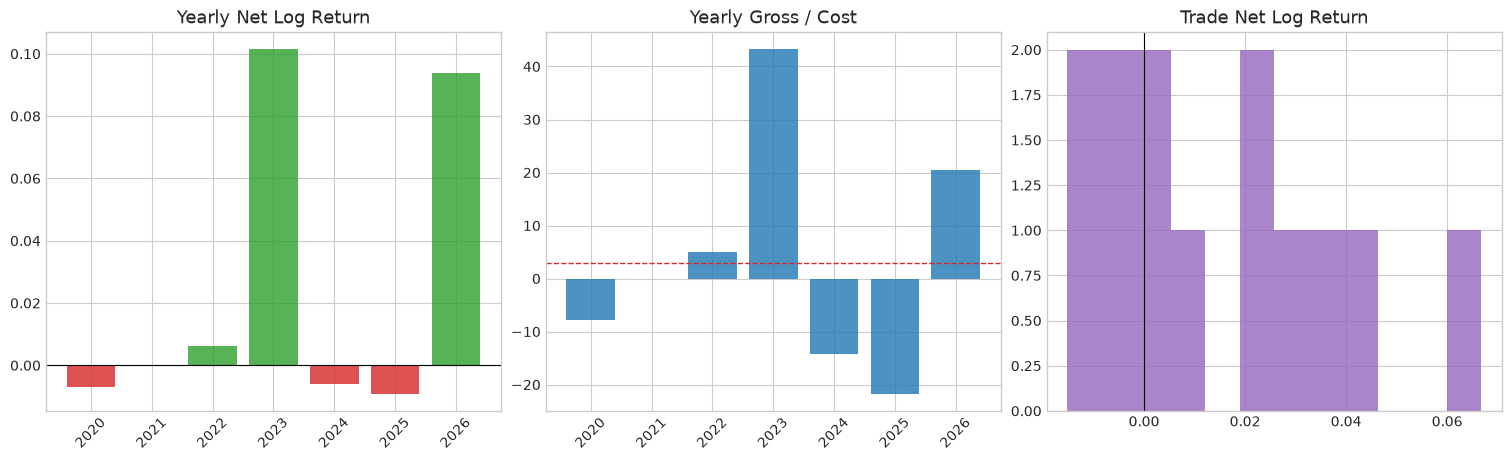

In [6]:
selected["cum_gross"] = selected["gross_return"].cumsum()
selected["cum_net"] = selected["net_return"].cumsum()
selected["drawdown"] = selected["cum_net"] - selected["cum_net"].cummax()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True, constrained_layout=True)
axes[0].plot(
    selected.index, selected["residual"], linewidth=1.0, label="HRC beta-hedged residual vs ALI"
)
axes[0].set_title("Residual")
axes[0].legend(loc="upper left")
axes[1].plot(selected.index, selected["zscore"], linewidth=1.0, label="robust z-score")
axes[1].axhline(2.0, color="tab:red", linestyle="--", linewidth=0.9)
axes[1].axhline(-2.0, color="tab:green", linestyle="--", linewidth=0.9)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Entry Signal")
axes[1].legend(loc="upper left")
axes[2].plot(
    selected.index, selected_positions.abs().sum(axis=1), linewidth=1.0, label="gross exposure"
)
axes[2].set_title("Exposure")
axes[2].legend(loc="upper left")
axes[3].plot(selected.index, selected["cum_gross"], label="gross", linewidth=1.1)
axes[3].plot(selected.index, selected["cum_net"], label="net", linewidth=1.1)
axes[3].set_title("Cumulative Log Return")
axes[3].legend(loc="upper left")
axes[3].xaxis.set_major_locator(mdates.YearLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
axes[0].bar(
    yearly["year"].astype(str),
    yearly["net_log_return"],
    color=np.where(yearly["net_log_return"] >= 0, "tab:green", "tab:red"),
    alpha=0.8,
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Yearly Net Log Return")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(yearly["year"].astype(str), yearly["gross_to_cost"], color="tab:blue", alpha=0.8)
axes[1].axhline(3.0, color="tab:red", linestyle="--", linewidth=1.0)
axes[1].set_title("Yearly Gross / Cost")
axes[1].tick_params(axis="x", rotation=45)
axes[2].hist(selected_trades["net_log_return"], bins=12, color="tab:purple", alpha=0.8)
axes[2].axvline(0.0, color="black", linewidth=0.8)
axes[2].set_title("Trade Net Log Return")
plt.show()

## 5. Interpretation Notes

This is an investigation, not a production claim. The result is economically interesting because gross/cost is high under conservative HRC costs, but the number of trades is small. The next validation step should be contract-level execution realism: bid/ask or trades around HRC active timestamps, contract rolls, and whether the daily close proxy is executable at the modeled cost.
